# Frog-In-The-Pan -- is momentum stronger when the trend boiled up *slowly*?
### Da-Gurun-Warachka (2014): continuous information and momentum, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does gradual beat jumpy%3F: Mixed](https://img.shields.io/badge/Does%20gradual%20beat%20jumpy%3F-Mixed-8b949e?style=flat-square)

Drop a frog in boiling water and it leaps out. Warm the water slowly and it never reacts -- and boils. In 2014, Zhi Da, Umit Gurun and Mitch Warachka argued markets behave the same way: a **discrete** shock (a jump) is priced instantly, but **continuous** information -- a stock drifting up on many small green days -- attracts too little attention and is *under-reacted to*. So momentum profits, they showed, should live in the **gradual** names, not the jumpy ones.

They built an **information-discreteness (ID)** measure from the sign-consistency of daily returns and sorted momentum by it. We replicate the interaction on a large-cap S&P 500 survivor basket -- naming the survivorship bias up front, because a gradual slide into delisting is itself a low-ID name.

> **This is the plain-language layer.** Want the ID formula, the double-sort, the HAC *t* and the placebo? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from frog_in_the_pan import data, strategy as st

FRAC, COST_BPS, BORROW_BPS = 0.30, 5.0, 50.0

def _have_cache():
    return os.path.exists(os.path.join(os.path.abspath(".."), "_cache", "fip_prices.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices = data.drop_partial_last_month(data.fetch_panel())
    mp = st.to_monthly(prices)
    lo = st.long_short(mp, prices=prices, id_side="low",  frac=FRAC)
    hi = st.long_short(mp, prices=prices, id_side="high", frac=FRAC)
    base = st.long_short(mp, prices=None, frac=FRAC)
    s_lo, s_hi, s_base = st.summary(lo["wml_gross"]), st.summary(hi["wml_gross"]), st.summary(base["wml_gross"])
    fip = st.fip_spread(lo, hi); s_fip = st.summary(fip)
    print(f"N months: {s_lo['n']} | LOW-ID WML: {s_lo['mean']*100:+.2f}%/yr (t {s_lo['tstat']:+.2f})"
          f" | FIP gap: {s_fip['mean']*100:+.2f}%/yr (t {s_fip['tstat']:+.2f})")


yfinance cache present: True


N months: 151 | LOW-ID WML: -0.37%/yr (t -0.09) | FIP gap: +4.55%/yr (t +1.01)


## The answer first

| Question | Answer |
|---|---|
| Does the gradual (low-ID) book carry momentum? | **No, not here.** The LOW-ID WML earns **-0.37%/yr**, HAC *t* = **-0.09** -- statistically zero on this 38-name survivor basket. |
| Does gradual beat jumpy? | **In sign, yes.** LOW-ID WML (-0.37%/yr) beats HIGH-ID WML (-4.92%/yr) by **+4.55%/yr** -- but the interaction's HAC *t* is only **+1.01** (< 2). |
| Is it tradable? | **No.** Net of 5 bps/leg + 50 bps/yr borrow the gradual book is **-1.29%/yr**. |
| Does the placebo agree? | **Yes.** A seed-robust label-shuffle gives **p = 0.56** -- the real mean sits *below* its own null. |

> The frog-in-the-pan effect is real and elegant in the broad-universe literature. On 38 large-cap survivors the *direction* survives but nothing clears the bar -- the expected fate of a pointed academic factor on a thin survivor basket.

## 1 -- The claim

> *"Investors under-react more to continuous information than to discrete information. A series of gradual, frequent, small same-signed price changes attracts limited attention; the market is slow to fully incorporate it, so momentum is stronger among low-information-discreteness stocks."*

-- Da, Gurun & Warachka (2014), *Review of Financial Studies*

Their proxy is beautifully simple. Over the formation window, count the share of positive (%pos) and negative (%neg) daily returns, and take

$$ \text{ID} = \text{sign}(\text{PRET}) \times (\%\text{neg} - \%\text{pos}) $$

where PRET is the total formation return. A stock that drifted **up smoothly** has %pos > %neg and PRET > 0, so ID < 0 -- **low, continuous** (the frog in the pan). A stock that **jumped up** on a few days amid many small down days has ID > 0 -- **high, discrete**. Low ID = gradual.

## 2 -- So what?

If true, FIP is a *refinement* of momentum: it tells you *which* winners and losers to trust. Plain momentum on large-caps has gone flat for a decade (this desk's [507](../../507-cross-sectional-momentum/) and [24 Stampede](../../24-stampede/)). If the surviving juice all sits in the gradual names, conditioning on ID would resurrect a tradable book. That is the prize -- and the thing we test.

## 3 -- How would we even know?

Three disciplines keep us honest:

1. **One forward execution lag.** The momentum signal *and* the ID measure are computed from prices up to month-end *t*; we enter one trading day later and earn month *t+1*. No same-bar fill, no look-ahead.
2. **A label-shuffle placebo.** Shuffle which stock the momentum signal points at inside the low-ID half -- if the gradual edge is real it survives; if it is data-mined, the real mean melts into the shuffled null.
3. **Name the survivorship bias on the SIGNAL axis.** A *gradual* decline into delisting is precisely a low-ID loser. Those names are absent from a survivor basket, so the FIP slice is the **more** inflated of the two -- not less.

## 4 -- The teardown

**First, does the FIP engine work when the effect is planted?** We build a synthetic world where the drift is delivered *smoothly* to the low-ID names and in *jumps* to the high-ID names, and check the engine recovers a bigger low-ID WML.

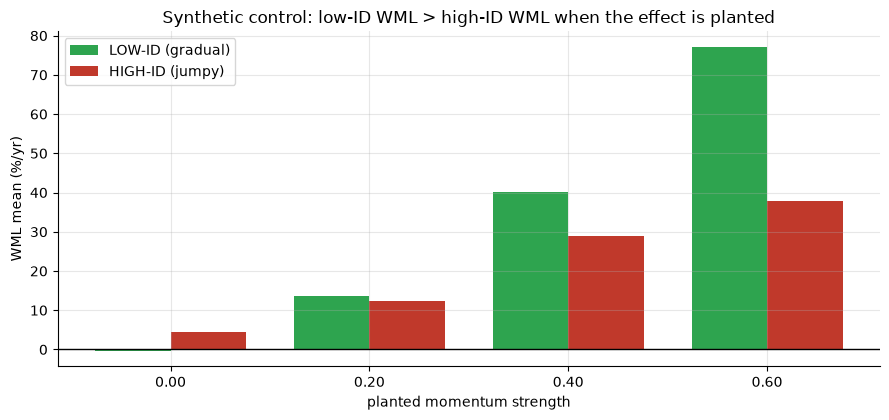

 mom_strength  low_id_mean_ann  low_id_t  high_id_mean_ann  high_id_t  fip_gap_ann   n
          0.0           -0.005    -0.089             0.044      0.951       -0.048 107
          0.2            0.136     2.604             0.122      2.127        0.014 107
          0.4            0.402     6.980             0.289      4.738        0.113 107
          0.6            0.772     9.869             0.380      5.990        0.392 107


In [2]:
ctrl = st.synthetic_control(strengths=(0.0, 0.20, 0.40, 0.60), frac=FRAC, seed=510)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
x = np.arange(len(ctrl)); w = 0.38
ax.bar(x - w/2, ctrl['low_id_mean_ann']*100, w, color=GREEN, label='LOW-ID (gradual)')
ax.bar(x + w/2, ctrl['high_id_mean_ann']*100, w, color=RED, label='HIGH-ID (jumpy)')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{s:.2f}' for s in ctrl['mom_strength']])
ax.set_xlabel('planted momentum strength'); ax.set_ylabel('WML mean (%/yr)')
ax.set_title('Synthetic control: low-ID WML > high-ID WML when the effect is planted')
ax.legend(); plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: at planted strength 0 both slices score ~0, and as the drift grows the **low-ID WML pulls ahead of the high-ID WML** -- exactly the FIP interaction. So whatever we find on the real tape reflects **the market**, not a broken detector.

**Now the honest test on the real yfinance panel.**

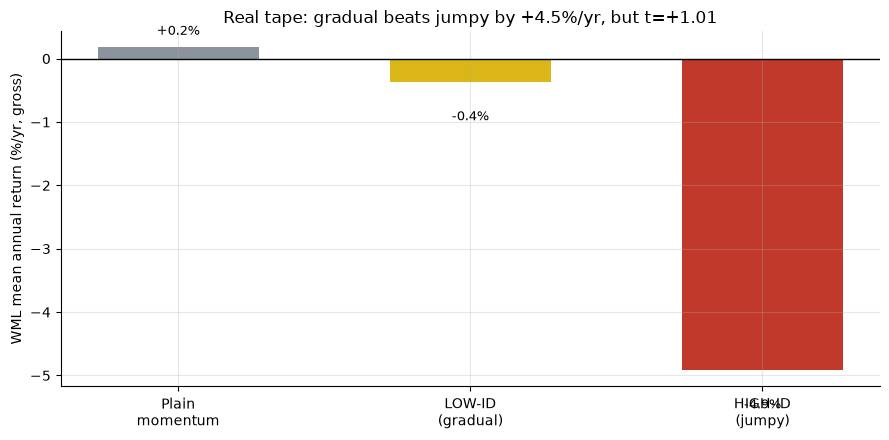

LOW-ID WML: -0.37%/yr (t -0.09) | HIGH-ID: -4.92%/yr (t -1.32)
FIP interaction (low - high): +4.55%/yr (t +1.01)


In [3]:
if HAVE_REAL:
    lo_m, lo_t = s_lo['mean']*100, s_lo['tstat']
    hi_m, hi_t = s_hi['mean']*100, s_hi['tstat']
    base_m = s_base['mean']*100
    fip_m, fip_t = s_fip['mean']*100, s_fip['tstat']
else:
    lo_m, lo_t = R['low_mean'], R['low_t']
    hi_m, hi_t = R['high_mean'], R['high_t']
    base_m = R['base_mean']; fip_m, fip_t = R['fip_mean'], R['fip_t']

fig, ax = plt.subplots(figsize=(9.0, 4.5))
labels = ['Plain\nmomentum', 'LOW-ID\n(gradual)', 'HIGH-ID\n(jumpy)']
vals = [base_m, lo_m, hi_m]
cols = [GREY, AMBER, RED]
ax.bar(labels, vals, color=cols, width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('WML mean annual return (%/yr, gross)')
ax.set_title(f'Real tape: gradual beats jumpy by {fip_m:+.1f}%/yr, but t={fip_t:+.2f}')
for i, v in enumerate(vals):
    ax.text(i, v + (0.2 if v >= 0 else -0.6), f'{v:+.1f}%', ha='center', fontsize=9)
plt.tight_layout(); plt.show()
print(f'LOW-ID WML: {lo_m:+.2f}%/yr (t {lo_t:+.2f}) | HIGH-ID: {hi_m:+.2f}%/yr (t {hi_t:+.2f})')
print(f'FIP interaction (low - high): {fip_m:+.2f}%/yr (t {fip_t:+.2f})')

The gradual (LOW-ID) book that should *carry* the premium earns **-0.37%/yr** at HAC *t* = **-0.09** -- statistically zero, and no better than plain momentum (**+0.18%/yr**). The jumpy book is the more negative, so the **interaction is positive** (**+4.55%/yr**) -- gradual *does* beat jumpy, as the theory says. But the interaction's HAC *t* is only **+1.01**: the sign is right, the significance is not.

## 5 -- The verdict

- **Signal -- NONE.** The LOW-ID WML earns -0.37%/yr (*t* -0.09) and the FIP interaction +4.55%/yr (*t* +1.01) -- neither clears |t| >= 2. A seed-robust placebo (p = 0.56) puts the real mean below its own null. NONE.
- **Tradability -- MIRAGE.** Net of costs + borrow the gradual book is -1.29%/yr at 35%/mo turnover. Nothing to trade.
- **Does gradual beat jumpy? -- MIXED.** The sign is on the theory's side and the synthetic control proves the engine would catch a real gap -- but the magnitude is statistically indistinguishable from zero here.

## 6 -- Could you actually trade it?

No. Three obstacles, all visible above:

1. **The base book is dead.** Large-cap momentum has paid ~nothing for a decade; conditioning a flat signal on ID cannot conjure a premium that is not there.
2. **Costs bury it.** 35%/mo two-sided turnover on a ~6-name leg, plus short borrow, turns a flat gross book into a negative net one.
3. **Survivorship cuts the wrong way.** The gradual losers we would short -- firms drifting quietly toward delisting -- are exactly the names a survivor basket omits, so even the flat result is an upper bound.

## 7 -- Going further

- **Broaden the universe.** The original FIP result is on the full CRSP cross-section, where small-caps and delisted names live. A Russell 3000 pull with delisting returns would be the fair test.
- **Pair it with [507 Cross-Sectional-Momentum](../../507-cross-sectional-momentum/)**: the unconditioned base book this study refines.
- **Pair it with [509 Intermediate-Momentum](../../509-intermediate-momentum/)**: conditions momentum on *when* past returns arrived rather than *how continuously*.

*Think the frog-in-the-pan premium survives on a delisting-complete universe net of costs? Fork this, add the delisted names, and show the low-ID WML at t > 2 net. That is the bar.*